In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import time
from scipy import ndimage

Создаём тестовое изображение с текстурированными объектами...
✅ Синтетическое изображение создано


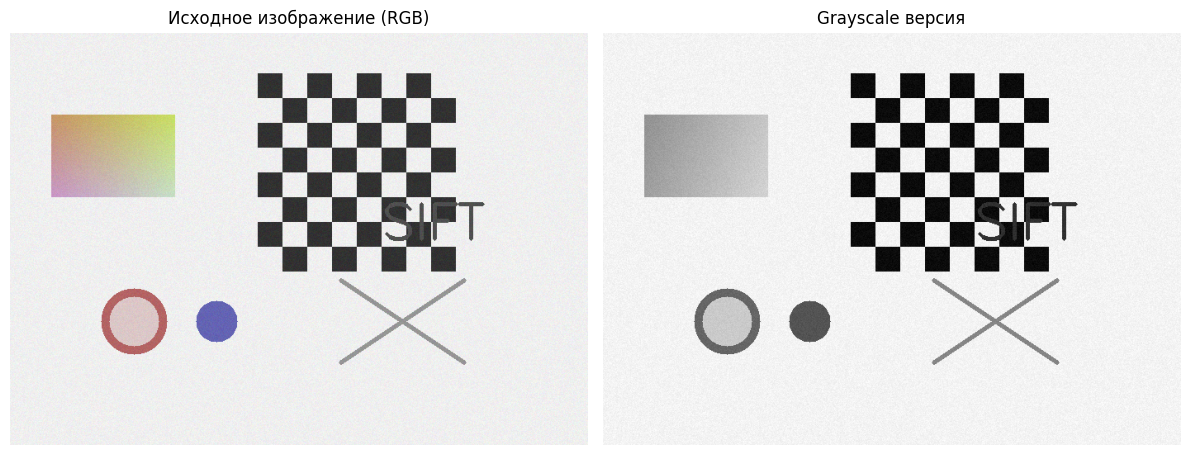

In [3]:
# Загрузка тестового изображения
img_path = 'sample.jpg'

if os.path.exists(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"Изображение загружено: {img_path}")
else:
    print("Создаём тестовое изображение с текстурированными объектами...")

    # Создаём изображение с различными объектами для детекции ключевых точек
    img = np.ones((500, 700, 3), dtype=np.uint8) * 240  # Светлый фон

    # Добавляем текстурированные области
    # Прямоугольник с градиентом
    for i in range(100, 200):
        for j in range(50, 200):
            img[i, j] = [100 + (i-100), 150 + (j-50)//2, 200]

    # Шахматная доска (много углов)
    square_size = 30
    for i in range(8):
        for j in range(8):
            if (i + j) % 2 == 0:
                y1, y2 = 50 + i*square_size, 50 + (i+1)*square_size
                x1, x2 = 300 + j*square_size, 300 + (j+1)*square_size
                img[y1:y2, x1:x2] = [50, 50, 50]

    # Круги разного размера
    cv2.circle(img, (150, 350), 40, (100, 100, 180), -1)
    cv2.circle(img, (150, 350), 30, (200, 200, 220), -1)
    cv2.circle(img, (250, 350), 25, (180, 100, 100), -1)

    # Линии под разными углами
    cv2.line(img, (400, 300), (550, 400), (150, 150, 150), 3)
    cv2.line(img, (400, 400), (550, 300), (150, 150, 150), 3)

    # Текст (много особенностей)
    cv2.putText(img, 'SIFT', (450, 250), cv2.FONT_HERSHEY_SIMPLEX, 2, (80, 80, 80), 3)

    # Добавляем небольшой шум для реалистичности
    noise = np.random.randint(-10, 10, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("✅ Синтетическое изображение создано")

# Преобразуем в grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Отображаем исходное изображение
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Исходное изображение (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale версия')
plt.axis('off')
plt.tight_layout()
plt.show()

Тестирование FAST детектора...


/tmp/ipython-input-3441304229.py:40: RuntimeWarning: overflow encountered in scalar subtract
  elif neighbor_value < pixel_value - threshold:
/tmp/ipython-input-3441304229.py:38: RuntimeWarning: overflow encountered in scalar add
  if neighbor_value > pixel_value + threshold:


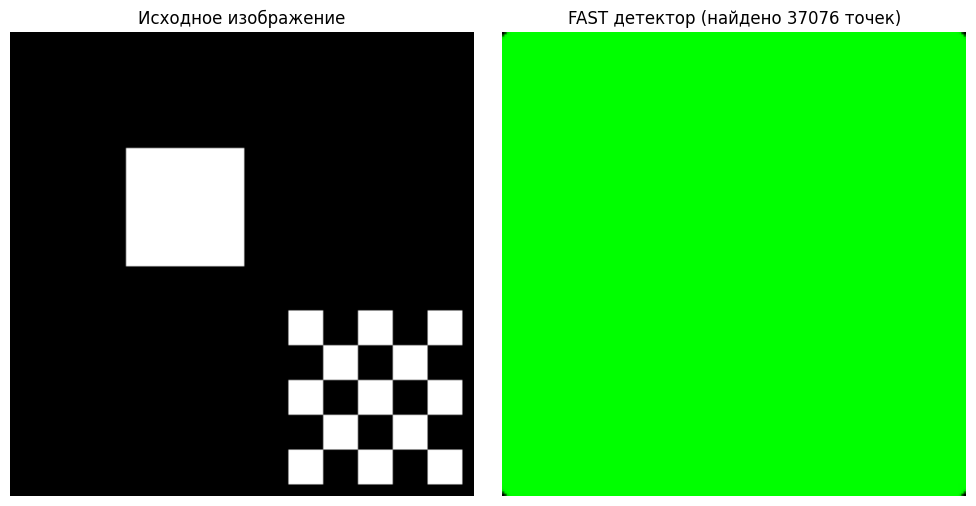

Найдено точек: 37076


In [4]:
# ============================================
# 1. РЕАЛИЗАЦИЯ УПРОЩЕННОГО FAST ДЕТЕКТОРА
# ============================================

def fast_detector_simple(image, threshold=30, n=12):
    """
    Упрощенная реализация FAST детектора углов.
    Проверяет 16 точек на окружности вокруг пикселя.

    Параметры:
    - image: одноканальное изображение
    - threshold: порог для определения угла
    - n: минимальное количество точек для угла (обычно 9-12)

    Возвращает:
    - keypoints: список ключевых точек
    """
    height, width = image.shape
    keypoints = []

    # Смещения для 16 точек на окружности радиусом 3
    circle_offsets = [
        (0, 3), (1, 3), (2, 2), (3, 1), (3, 0), (3, -1), (2, -2), (1, -3),
        (0, -3), (-1, -3), (-2, -2), (-3, -1), (-3, 0), (-3, 1), (-2, 2), (-1, 3)
    ]

    # Проходим по всем пикселям, кроме границ
    for y in range(3, height - 3):
        for x in range(3, width - 3):
            pixel_value = image[y, x]
            count_bright = 0
            count_dark = 0

            # Проверяем 16 точек
            for dx, dy in circle_offsets:
                neighbor_value = image[y + dy, x + dx]

                if neighbor_value > pixel_value + threshold:
                    count_bright += 1
                elif neighbor_value < pixel_value - threshold:
                    count_dark += 1

            # Если достаточно точек ярче или темнее
            if count_bright >= n or count_dark >= n:
                keypoints.append(cv2.KeyPoint(x, y, 3))

    return keypoints

def test_fast_detector():
    """Тестирование FAST детектора на тестовом изображении"""
    # Создаем тестовое изображение с углами
    test_img = np.zeros((200, 200), dtype=np.uint8)

    # Рисуем угол
    cv2.rectangle(test_img, (50, 50), (100, 100), 255, -1)

    # Рисуем шахматную доску
    for i in range(5):
        for j in range(5):
            if (i + j) % 2 == 0:
                x1, y1 = 120 + i*15, 120 + j*15
                x2, y2 = x1 + 15, y1 + 15
                test_img[y1:y2, x1:x2] = 255

    # Детектируем углы
    keypoints = fast_detector_simple(test_img, threshold=20, n=9)

    # Визуализируем
    result = cv2.drawKeypoints(test_img, keypoints, None, color=(0, 255, 0))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(test_img, cmap='gray')
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title(f'FAST детектор (найдено {len(keypoints)} точек)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return len(keypoints)

# Запускаем тест FAST детектора
print("Тестирование FAST детектора...")
fast_points = test_fast_detector()
print(f"Найдено точек: {fast_points}")


СРАВНЕНИЕ ДЕТЕКТОРОВ НА РАЗНЫХ ТИПАХ ИЗОБРАЖЕНИЙ
Создаем синтетическое изображение: texture
Создаем синтетическое изображение: architecture
Создаем синтетическое изображение: nature
Создаем синтетическое изображение: objects
Создаем синтетическое изображение: faces
SIFT на texture: 2673 точек, время: 0.234 сек
ORB на texture: 1000 точек, время: 0.019 сек


/tmp/ipython-input-3441304229.py:40: RuntimeWarning: overflow encountered in scalar subtract
  elif neighbor_value < pixel_value - threshold:


FAST на texture: 58276 точек, время: 5.210 сек
SIFT на architecture: 76 точек, время: 0.142 сек
ORB на architecture: 382 точек, время: 0.012 сек
FAST на architecture: 121136 точек, время: 4.228 сек
SIFT на nature: 71 точек, время: 0.040 сек
ORB на nature: 404 точек, время: 0.004 сек
FAST на nature: 79347 точек, время: 2.506 сек
SIFT на objects: 40 точек, время: 0.049 сек
ORB на objects: 299 точек, время: 0.003 сек
FAST на objects: 141376 точек, время: 4.517 сек
SIFT на faces: 44 точек, время: 0.066 сек
ORB на faces: 491 точек, время: 0.007 сек
FAST на faces: 131789 точек, время: 4.062 сек


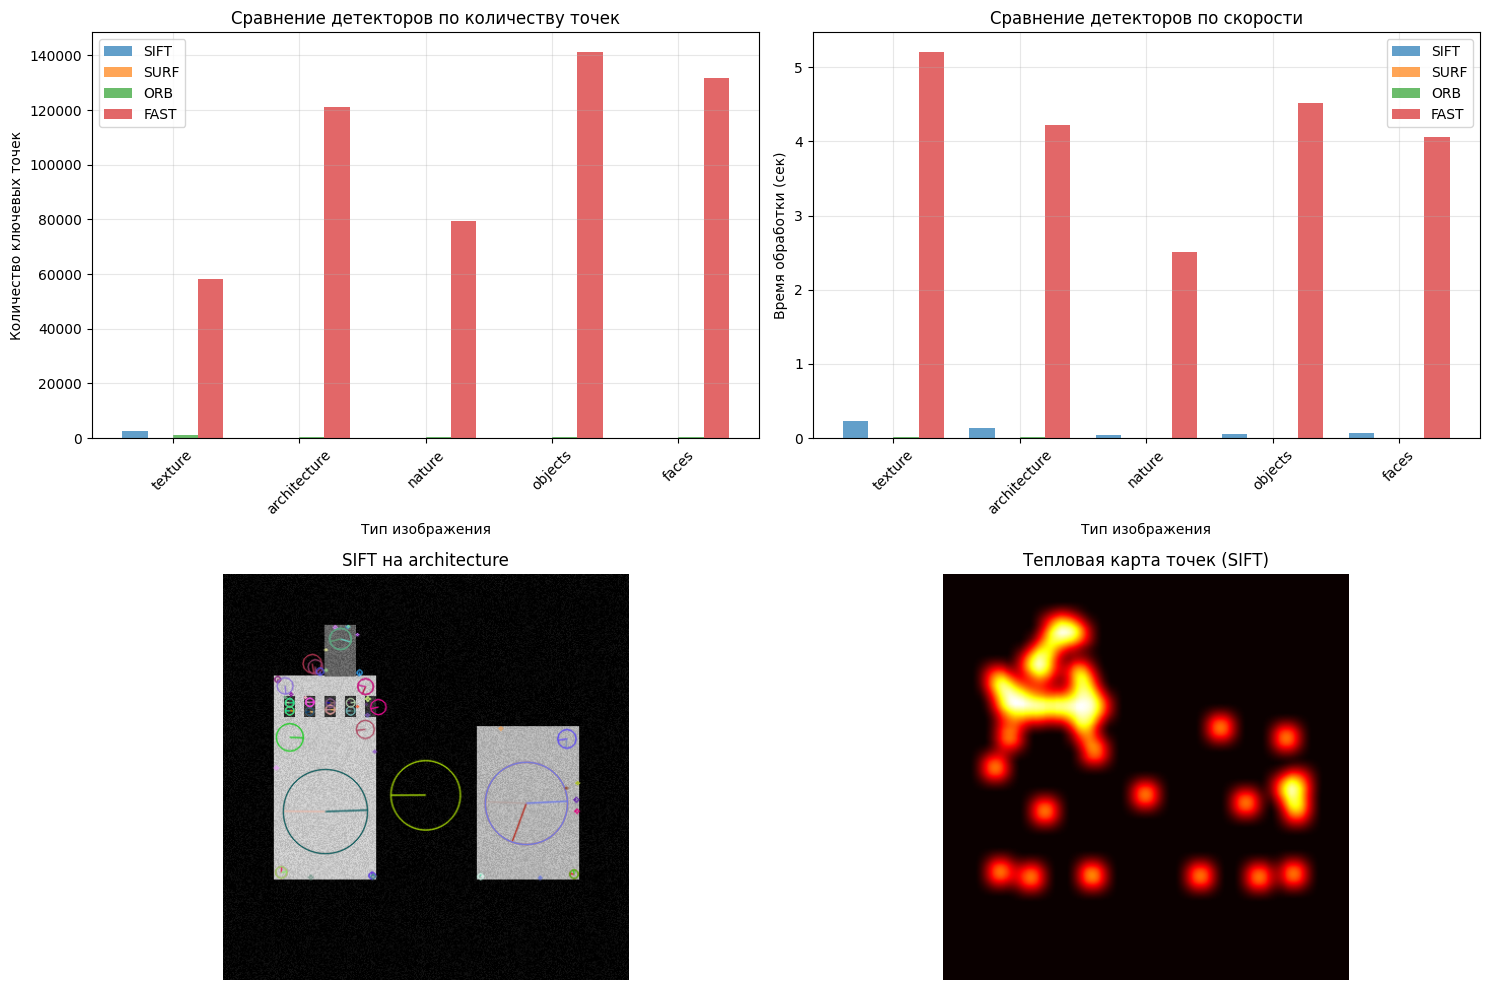


РЕЗУЛЬТАТЫ СРАВНЕНИЯ ДЕТЕКТОРОВ
Детектор   Текстура   Архитектура  Природа    Объекты    Лица      
------------------------------------------------------------
SIFT      2673        76          71          40          44          
SURF      0           0           0           0           0           
ORB       1000        382         404         299         491         
FAST      58276       121136      79347       141376      131789      


In [5]:
# ============================================
# 2. СРАВНЕНИЕ ДЕТЕКТОРОВ НА РАЗНЫХ ТИПАХ ИЗОБРАЖЕНИЙ
# ============================================

def load_or_create_test_images():
    """Загрузка или создание тестовых изображений разных типов"""
    image_types = ['texture', 'architecture', 'nature', 'objects', 'faces']
    images = {}

    for img_type in image_types:
        img_path = f'{img_type}.jpg'

        if os.path.exists(img_path):
            # Загружаем существующее изображение
            img = cv2.imread(img_path)
            images[img_type] = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            print(f"Загружено: {img_type}")
        else:
            # Создаем синтетические изображения для теста
            print(f"Создаем синтетическое изображение: {img_type}")
            img = create_synthetic_image(img_type)
            images[img_type] = img

    return images

def create_synthetic_image(img_type):
    """Создание синтетических изображений разных типов"""
    img = np.zeros((400, 400), dtype=np.uint8)

    if img_type == 'texture':
        # Текстура (дерево/ткань)
        for i in range(20):
            for j in range(20):
                intensity = np.random.randint(100, 200)
                cv2.rectangle(img, (i*20, j*20), (i*20+15, j*20+15), intensity, -1)

    elif img_type == 'architecture':
        # Архитектура (здания)
        cv2.rectangle(img, (50, 100), (150, 300), 200, -1)  # Здание
        cv2.rectangle(img, (250, 150), (350, 300), 180, -1)  # Второе здание
        cv2.rectangle(img, (100, 50), (130, 100), 100, -1)   # Башня
        for i in range(5):
            cv2.rectangle(img, (60+i*20, 120), (70+i*20, 140), 50, -1)  # Окна

    elif img_type == 'nature':
        # Природа (пейзаж)
        cv2.rectangle(img, (0, 250), (400, 400), 150, -1)  # Земля
        cv2.circle(img, (200, 150), 50, 200, -1)  # Солнце
        cv2.ellipse(img, (100, 200), (60, 30), 0, 0, 360, 100, -1)  # Облако
        cv2.ellipse(img, (300, 180), (80, 40), 0, 0, 360, 100, -1)  # Облако

    elif img_type == 'objects':
        # Объекты (предметы на столе)
        cv2.circle(img, (100, 100), 30, 200, -1)  # Чашка
        cv2.rectangle(img, (200, 150), (300, 200), 180, -1)  # Книга
        cv2.rectangle(img, (150, 250), (250, 300), 160, -1)  # Телефон
        cv2.circle(img, (350, 150), 25, 140, -1)  # Яблоко

    elif img_type == 'faces':
        # Лица (портрет)
        cv2.ellipse(img, (200, 200), (80, 100), 0, 0, 360, 180, -1)  # Лицо
        cv2.circle(img, (160, 170), 15, 100, -1)  # Левый глаз
        cv2.circle(img, (240, 170), 15, 100, -1)  # Правый глаз
        cv2.ellipse(img, (200, 240), (40, 20), 0, 0, 360, 100, -1)  # Рот

    # Добавляем немного шума для реалистичности
    noise = np.random.randint(-20, 20, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img

def compare_detectors_on_images():
    """Сравнение всех детекторов на разных типах изображений"""
    # Загружаем изображения
    images = load_or_create_test_images()

    # Инициализируем детекторы
    detectors = {}

    try:
        detectors['SIFT'] = cv2.SIFT_create()
    except:
        detectors['SIFT'] = None

    try:
        detectors['SURF'] = cv2.xfeatures2d.SURF_create(400)
    except:
        detectors['SURF'] = None

    try:
        detectors['ORB'] = cv2.ORB_create(nfeatures=1000)
    except:
        detectors['ORB'] = None

    # Добавляем наш FAST детектор
    detectors['FAST'] = 'custom'

    # Результаты
    results = {}

    # Тестируем на каждом типе изображений
    for img_type, img in images.items():
        results[img_type] = {}

        for det_name, detector in detectors.items():
            start_time = time.time()

            if det_name == 'FAST':
                # Используем наш FAST детектор
                keypoints = fast_detector_simple(img, threshold=20, n=9)
                num_points = len(keypoints)
                descriptors = None
            elif detector is not None:
                # Используем встроенные детекторы OpenCV
                keypoints, descriptors = detector.detectAndCompute(img, None)
                num_points = len(keypoints)
            else:
                num_points = 0
                keypoints = []

            end_time = time.time()

            results[img_type][det_name] = {
                'count': num_points,
                'time': end_time - start_time,
                'keypoints': keypoints
            }

            if detector is not None and det_name != 'FAST':
                print(f"{det_name} на {img_type}: {num_points} точек, время: {end_time-start_time:.3f} сек")
            elif det_name == 'FAST':
                print(f"FAST на {img_type}: {num_points} точек, время: {end_time-start_time:.3f} сек")

    # Визуализация результатов
    visualize_comparison_results(images, results, detectors)

    return results

def visualize_comparison_results(images, results, detectors):
    """Визуализация результатов сравнения детекторов"""
    # 1. График количества точек по типам изображений
    fig = plt.figure(figsize=(15, 10))

    image_types = list(images.keys())
    detector_names = [name for name in detectors.keys()]

    # Подготавливаем данные для графика
    plot_data = []
    for det_name in detector_names:
        counts = []
        for img_type in image_types:
            if det_name in results[img_type]:
                counts.append(results[img_type][det_name]['count'])
            else:
                counts.append(0)
        plot_data.append(counts)

    # Строим групповой график
    ax1 = plt.subplot(2, 2, 1)
    x = np.arange(len(image_types))
    width = 0.2

    for i, (det_name, counts) in enumerate(zip(detector_names, plot_data)):
        offset = (i - len(detector_names)/2) * width + width/2
        ax1.bar(x + offset, counts, width, label=det_name, alpha=0.7)

    ax1.set_xlabel('Тип изображения')
    ax1.set_ylabel('Количество ключевых точек')
    ax1.set_title('Сравнение детекторов по количеству точек')
    ax1.set_xticks(x)
    ax1.set_xticklabels(image_types, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. График времени работы
    ax2 = plt.subplot(2, 2, 2)

    time_data = []
    for det_name in detector_names:
        times = []
        for img_type in image_types:
            if det_name in results[img_type]:
                times.append(results[img_type][det_name]['time'])
            else:
                times.append(0)
        time_data.append(times)

    for i, (det_name, times) in enumerate(zip(detector_names, time_data)):
        offset = (i - len(detector_names)/2) * width + width/2
        ax2.bar(x + offset, times, width, label=det_name, alpha=0.7)

    ax2.set_xlabel('Тип изображения')
    ax2.set_ylabel('Время обработки (сек)')
    ax2.set_title('Сравнение детекторов по скорости')
    ax2.set_xticks(x)
    ax2.set_xticklabels(image_types, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Пример визуализации ключевых точек для одного изображения
    ax3 = plt.subplot(2, 2, 3)
    sample_img_type = 'architecture'
    sample_img = images[sample_img_type]

    # Собираем все ключевые точки для визуализации
    all_kp_images = []
    for det_name in detector_names[:3]:  # Первые 3 детектора
        if det_name in results[sample_img_type]:
            kp = results[sample_img_type][det_name]['keypoints']
            if len(kp) > 0:
                img_kp = cv2.drawKeypoints(
                    sample_img, kp, None,
                    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
                )
                all_kp_images.append((det_name, img_kp))

    # Показываем первую визуализацию
    if all_kp_images:
        ax3.imshow(all_kp_images[0][1], cmap='gray')
        ax3.set_title(f'{all_kp_images[0][0]} на {sample_img_type}')
        ax3.axis('off')

    # 4. Тепловая карта распределения точек
    ax4 = plt.subplot(2, 2, 4)

    # Создаем тепловую карту для SIFT (если есть)
    if 'SIFT' in results[sample_img_type]:
        kp = results[sample_img_type]['SIFT']['keypoints']
        if len(kp) > 0:
            # Создаем тепловую карту
            heatmap = np.zeros(sample_img.shape)
            for kp_point in kp:
                x, y = int(kp_point.pt[0]), int(kp_point.pt[1])
                if 0 <= x < heatmap.shape[1] and 0 <= y < heatmap.shape[0]:
                    # Добавляем гауссово размытие вокруг точки
                    cv2.circle(heatmap, (x, y), 10, 1, -1)

            # Размываем для получения плавной карты
            heatmap = cv2.GaussianBlur(heatmap, (31, 31), 10)

            ax4.imshow(heatmap, cmap='hot')
            ax4.set_title('Тепловая карта точек (SIFT)')
            ax4.axis('off')

    plt.tight_layout()
    plt.show()

    # 5. Таблица результатов
    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ ДЕТЕКТОРОВ")
    print("="*60)
    print(f"{'Детектор':<10} {'Текстура':<10} {'Архитектура':<12} {'Природа':<10} {'Объекты':<10} {'Лица':<10}")
    print("-"*60)

    for det_name in detector_names:
        row = f"{det_name:<10}"
        for img_type in image_types:
            if det_name in results[img_type]:
                count = results[img_type][det_name]['count']
                row += f"{count:<12}"
            else:
                row += f"{'N/A':<12}"
        print(row)

# Запускаем сравнение детекторов
print("\n" + "="*60)
print("СРАВНЕНИЕ ДЕТЕКТОРОВ НА РАЗНЫХ ТИПАХ ИЗОБРАЖЕНИЙ")
print("="*60)
comparison_results = compare_detectors_on_images()



ИССЛЕДОВАНИЕ ЭКСТРЕМАЛЬНЫХ ТРАНСФОРМАЦИЙ


/tmp/ipython-input-3441304229.py:40: RuntimeWarning: overflow encountered in scalar subtract
  elif neighbor_value < pixel_value - threshold:
/tmp/ipython-input-3441304229.py:38: RuntimeWarning: overflow encountered in scalar add
  if neighbor_value > pixel_value + threshold:


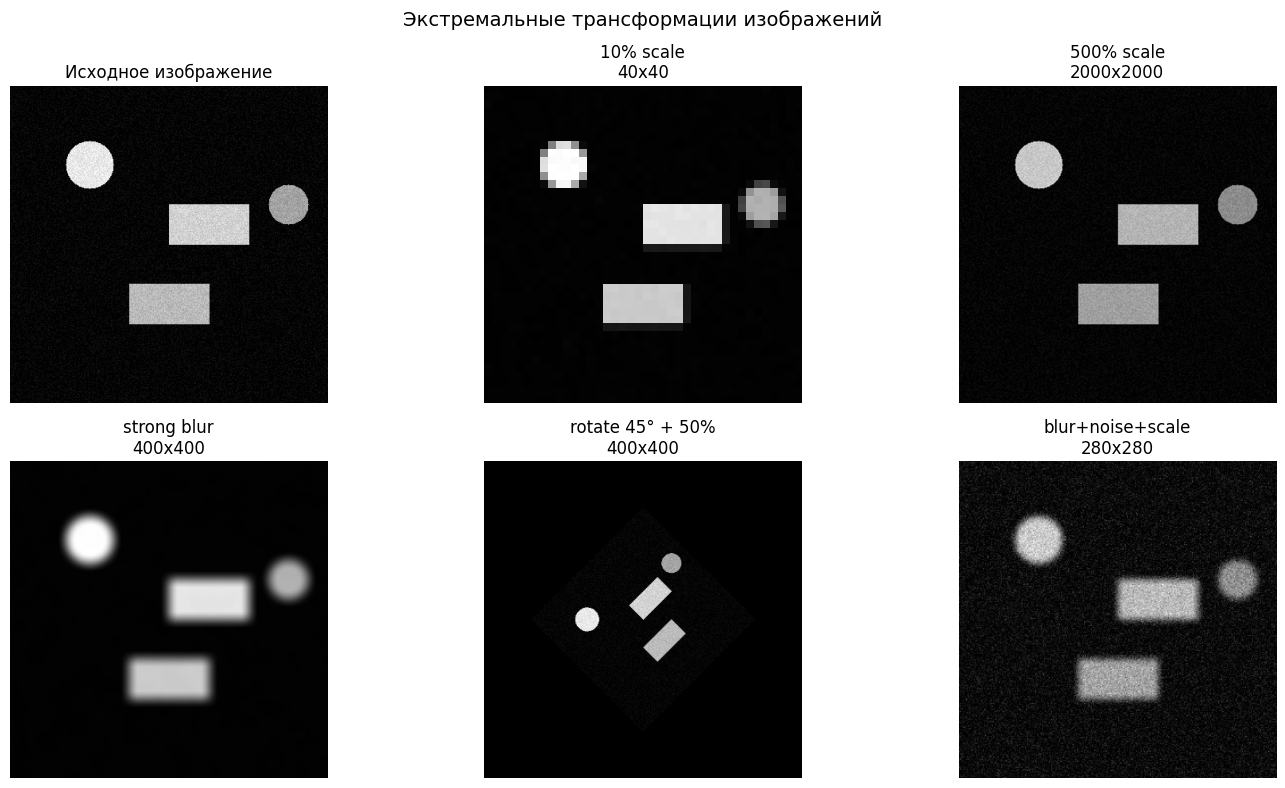

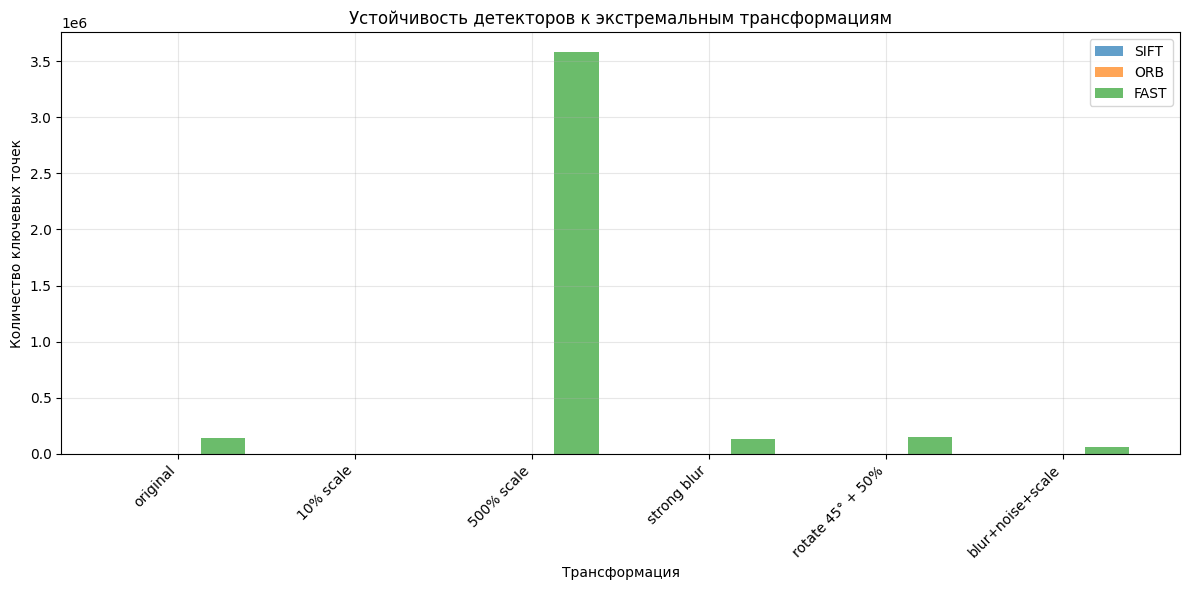


УСТОЙЧИВОСТЬ К ЭКСТРЕМАЛЬНЫМ ТРАНСФОРМАЦИЯМ (% от исходного)
Детектор        Исходное     10% scale         500% scale        strong blur       rotate 45° + 50   blur+noise+scal  
--------------------------------------------------------------------------------
SIFT            35             42.9% (15  ) 2880.0% (1008)   48.6% (17  )   82.9% (29  )   57.1% (20  )
ORB             298             0.0% (0   )  335.6% (1000)    8.4% (25  )   98.7% (294 )  176.5% (526 )
FAST            141340          0.8% (1076) 2531.2% (3577601)   94.1% (132963)  107.2% (151513)   40.2% (56805)

ВРЕМЯ ОБРАБОТКИ ПРИ ЭКСТРЕМАЛЬНЫХ ТРАНСФОРМАЦИЯХ (секунды)

SIFT:
  original                 : 0.1429 сек
  10% scale                : 0.0048 сек
  500% scale               : 1.5299 сек
  strong blur              : 0.0340 сек
  rotate 45° + 50%         : 0.0564 сек
  blur+noise+scale         : 0.0165 сек
  Общее время              : 1.7845 сек

ORB:
  original                 : 0.0033 сек
  10% scale              

In [6]:
# ============================================
# 3. ИССЛЕДОВАНИЕ ЭКСТРЕМАЛЬНЫХ ТРАНСФОРМАЦИЙ
# ============================================

def test_extreme_transformations():
    """Тестирование детекторов на экстремальных трансформациях"""

    # Загружаем тестовое изображение
    test_img = create_synthetic_image('objects')

    # Создаем экстремальные трансформации
    transformations = {}

    # 1. Очень маленький масштаб (10%)
    transformations['10% scale'] = cv2.resize(test_img, None, fx=0.1, fy=0.1,
                                              interpolation=cv2.INTER_AREA)

    # 2. Очень большой масштаб (500%)
    transformations['500% scale'] = cv2.resize(test_img, None, fx=5.0, fy=5.0,
                                               interpolation=cv2.INTER_CUBIC)

    # 3. Сильное размытие (21x21)
    transformations['strong blur'] = cv2.GaussianBlur(test_img, (21, 21), 7)

    # 4. Поворот на 45° + масштаб 50%
    rows, cols = test_img.shape
    M = cv2.getRotationMatrix2D((cols//2, rows//2), 45, 0.5)
    transformations['rotate 45° + 50%'] = cv2.warpAffine(test_img, M, (cols, rows))

    # 5. Комбинированная трансформация: размытие + шум + сжатие
    blurred = cv2.GaussianBlur(test_img, (15, 15), 5)
    noise = np.random.normal(0, 25, blurred.shape).astype(np.int16)
    noisy = np.clip(blurred.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    transformations['blur+noise+scale'] = cv2.resize(noisy, None, fx=0.7, fy=0.7)

    # Инициализируем детекторы
    detectors = {}
    try:
        detectors['SIFT'] = cv2.SIFT_create()
    except:
        detectors['SIFT'] = None

    try:
        detectors['ORB'] = cv2.ORB_create(nfeatures=1000)
    except:
        detectors['ORB'] = None

    detectors['FAST'] = 'custom'

    # Тестируем каждый детектор на каждой трансформации
    results_extreme = {}

    for det_name, detector in detectors.items():
        results_extreme[det_name] = {}

        # Тестируем на исходном изображении
        start_time = time.time()
        if det_name == 'FAST':
            kp_orig = fast_detector_simple(test_img, threshold=20, n=9)
            count_orig = len(kp_orig)
        elif detector is not None:
            kp_orig, _ = detector.detectAndCompute(test_img, None)
            count_orig = len(kp_orig)
        else:
            count_orig = 0

        results_extreme[det_name]['original'] = {
            'count': count_orig,
            'time': time.time() - start_time
        }

        # Тестируем на трансформациях
        for trans_name, trans_img in transformations.items():
            start_time = time.time()

            if det_name == 'FAST':
                kp = fast_detector_simple(trans_img, threshold=20, n=9)
                count = len(kp)
            elif detector is not None:
                kp, _ = detector.detectAndCompute(trans_img, None)
                count = len(kp)
            else:
                count = 0

            results_extreme[det_name][trans_name] = {
                'count': count,
                'time': time.time() - start_time,
                'image': trans_img
            }

    # Визуализируем результаты
    visualize_extreme_results(test_img, transformations, results_extreme, detectors)

    return results_extreme

def visualize_extreme_results(original_img, transformations, results, detectors):
    """Визуализация результатов экстремальных трансформаций"""

    # 1. Отображаем исходное изображение и трансформации
    fig = plt.figure(figsize=(15, 8))

    # Исходное изображение
    ax1 = plt.subplot(2, 3, 1)
    ax1.imshow(original_img, cmap='gray')
    ax1.set_title('Исходное изображение')
    ax1.axis('off')

    # Трансформации
    for i, (trans_name, trans_img) in enumerate(list(transformations.items())[:5]):
        ax = plt.subplot(2, 3, i+2)
        ax.imshow(trans_img, cmap='gray')
        ax.set_title(f'{trans_name}\n{trans_img.shape[1]}x{trans_img.shape[0]}')
        ax.axis('off')

    plt.suptitle('Экстремальные трансформации изображений', fontsize=14)
    plt.tight_layout()
    plt.show()

    # 2. График сохранения точек после трансформаций
    fig, ax = plt.subplots(figsize=(12, 6))

    detector_names = list(detectors.keys())
    transform_names = ['original'] + list(transformations.keys())

    # Подготовка данных
    bar_data = {}
    for det_name in detector_names:
        if det_name in results:
            counts = []
            for trans_name in transform_names:
                if trans_name in results[det_name]:
                    counts.append(results[det_name][trans_name]['count'])
                else:
                    counts.append(0)
            bar_data[det_name] = counts

    # Построение графика
    x = np.arange(len(transform_names))
    width = 0.25

    for i, (det_name, counts) in enumerate(bar_data.items()):
        offset = (i - len(detector_names)/2) * width + width/2
        ax.bar(x + offset, counts, width, label=det_name, alpha=0.7)

    ax.set_xlabel('Трансформация')
    ax.set_ylabel('Количество ключевых точек')
    ax.set_title('Устойчивость детекторов к экстремальным трансформациям')
    ax.set_xticks(x)
    ax.set_xticklabels(transform_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 3. Таблица процентного сохранения точек
    print("\n" + "="*80)
    print("УСТОЙЧИВОСТЬ К ЭКСТРЕМАЛЬНЫМ ТРАНСФОРМАЦИЯМ (% от исходного)")
    print("="*80)

    # Заголовок таблицы
    header = f"{'Детектор':<15} {'Исходное':<12}"
    for trans_name in transformations.keys():
        header += f" {trans_name[:15]:<17}"
    print(header)
    print("-"*80)

    # Данные таблицы
    for det_name in detector_names:
        if det_name in results:
            original_count = results[det_name]['original']['count']
            row = f"{det_name:<15} {original_count:<12}"

            for trans_name in transformations.keys():
                if trans_name in results[det_name]:
                    trans_count = results[det_name][trans_name]['count']
                    if original_count > 0:
                        percentage = (trans_count / original_count) * 100
                        row += f" {percentage:>6.1f}% ({trans_count:<4})"
                    else:
                        row += f" {'N/A':>12}"
                else:
                    row += f" {'N/A':>12}"

            print(row)

    # 4. Анализ времени обработки
    print("\n" + "="*80)
    print("ВРЕМЯ ОБРАБОТКИ ПРИ ЭКСТРЕМАЛЬНЫХ ТРАНСФОРМАЦИЯХ (секунды)")
    print("="*80)

    for det_name in detector_names:
        if det_name in results:
            print(f"\n{det_name}:")
            total_time = 0
            for trans_name in ['original'] + list(transformations.keys()):
                if trans_name in results[det_name]:
                    trans_time = results[det_name][trans_name]['time']
                    total_time += trans_time
                    print(f"  {trans_name:<25}: {trans_time:.4f} сек")
            print(f"  {'Общее время':<25}: {total_time:.4f} сек")

# Запускаем тестирование экстремальных трансформаций
print("\n" + "="*60)
print("ИССЛЕДОВАНИЕ ЭКСТРЕМАЛЬНЫХ ТРАНСФОРМАЦИЙ")
print("="*60)
extreme_results = test_extreme_transformations()